# Decision Tree — Attrition Prediction

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Source
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE


## Decision Tree Implementation (From Scratch)

In [15]:
class DecisionNode:
  def __init__(self, impurity=None, feature_index=None, threshold=None, left=None, right=None):
    self.left = left
    self.right = right
    # The largest impurity value of this node
    self.impurity = impurity
    # Index of the feature which make the best fit for this node.
    self.feature_index = feature_index
    # The threshold value for that feature to make the split.
    self.threshold = threshold

class LeafNode:
  def __init__(self, value):
    self.prediction_value = value

class DecisionTreeClassifierFromScratch:
  def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=10, criterion='gini'):
    self.root = None
    self.min_sample_split = min_sample_split
    self.min_impurity = min_impurity
    self.max_depth = max_depth
    self.impurity_function = self._calculate_information_gain
    if criterion == 'entropy':
      self.criterion = self._entropy
      self.criterion_name = criterion
    else:
      self.criterion = self._gini_index
      self.criterion_name = 'gini'

  def _gini_index(self, y):
    gini = 1
    unique_value = np.unique(y)
    for val in unique_value:
      # probability of that class.
      p = np.sum(y == val) / len(y)
      gini += -np.square(p)
    return gini

  def _entropy(self, y):
    entropy = 0
    unique_value = np.unique(y)
    for val in unique_value:
      # probability of that class.
      p = np.sum(y == val) / len(y)
      entropy += -p * np.log2(p)
    return entropy

  def _calculate_information_gain(self, y, y1, y2):
    # :param y: target value.
    # :param y1: target value for dataset in the true split/right branch.
    # :param y2: target value for dataset in the false split/left branch.

    # propobility of true values.
    p = len(y1) / len(y)
    info_gain = self.criterion(y) - p * self.criterion(y1) - (1 - p) * self.criterion(y2)
    return info_gain

  def _leaf_value_calculation(self, y):
    most_frequent_label = None
    max_count = 0
    unique_labels = np.unique(y)
    # iterate over all the unique values and find their frequentcy count.
    for label in unique_labels:
      count = len( y[y == label])
      if count > max_count:
        most_frequent_label = label
        max_count = count
    return most_frequent_label

  def _partition_dataset(self, Xy, feature_index, threshold):
    col = Xy[:, feature_index]
    X_1 = Xy[col >= threshold]
    X_2 = Xy[col < threshold]

    return X_1, X_2

  def _find_best_split(self, Xy):
    best_question = tuple()
    best_datasplit = {}
    largest_impurity = 0
    n_features = (Xy.shape[1] - 1)
    # iterate over all the features.
    for feature_index in range(n_features):
      # find the unique values in that feature.
      unique_value = set(s for s in Xy[:,feature_index])
      # iterate over all the unique values to find the impurity.
      for threshold in unique_value:
        # split the dataset based on the feature value.
        true_xy, false_xy = self._partition_dataset(Xy, feature_index, threshold)

        # skip the node which has any on type 0. because this means it is already pure.
        if len(true_xy) > 0 and len(false_xy) > 0:
          # find the y values.
          y = Xy[:, -1]
          true_y = true_xy[:, -1]
          false_y = false_xy[:, -1]
          # calculate the impurity function.
          impurity = self.impurity_function(y, true_y, false_y)

          # if the calculated impurity is larger than save this value for comaparison (highest gain).
          if impurity > largest_impurity:
            largest_impurity = impurity
            best_question = (feature_index, threshold)
            best_datasplit = {
              "leftX": true_xy[:, :n_features],   # X of left subtree
              "lefty": true_xy[:, n_features:],   # y of left subtree
              "rightX": false_xy[:, :n_features],  # X of right subtree
              "righty": false_xy[:, n_features:]   # y of right subtree
            }

    return largest_impurity, best_question, best_datasplit

  def _build_tree(self, X, y, current_depth=0):
    n_samples , n_features = X.shape
    # Add y as last column of X
    Xy = np.column_stack((X, y))
    # find the Information gain on each feature each values and return the question which splits the data very well
    if (n_samples >= self.min_sample_split) and (current_depth < self.max_depth):
      # find the best split/ which question split the data well.
      impurity, question, best_datasplit = self._find_best_split(Xy)
      if impurity > self.min_impurity:
        # Build subtrees for the right and left branch.
        true_branch = self._build_tree(best_datasplit["leftX"], best_datasplit["lefty"], current_depth + 1)
        false_branch = self._build_tree(best_datasplit["rightX"], best_datasplit["righty"], current_depth + 1)
        return DecisionNode(impurity=impurity, feature_index=question[0], threshold=question[1],
                            left=true_branch, right=false_branch)

    leaf_value = self._leaf_value_calculation(y)
    return LeafNode(value=leaf_value)

  def fit(self, X, y):
    self.root = self._build_tree(X, y, current_depth=0)

  def predict_sample(self, x, tree=None):
    if isinstance(tree , LeafNode):
      return tree.prediction_value

    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right

    if isinstance(feature_value, int) or isinstance(feature_value, float):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left

    return self.predict_sample(x, branch)

  def predict(self, test_X):
    x = np.array(test_X)
    y_pred = [self.predict_sample(sample) for sample in x]
    y_pred = np.array(y_pred)
    return y_pred

  def draw_tree(self):
    self._draw_tree(self.root)

  def _draw_tree(self, tree = None, indentation = " ", depth=0):
    if isinstance(tree , LeafNode):
      print(indentation,"The predicted value -->", tree.prediction_value)
      return
    else:
      print(indentation,f"({depth}) Is {tree.feature_index}>={tree.threshold}?"
            f": {self.criterion_name}:{tree.impurity:.2f}")
      if tree.left is not None:
          print (indentation + '----- True branch :)')
          self._draw_tree(tree.left, indentation + "  ", depth+1)
      if tree.right is not None:
          print (indentation + '----- False branch :)')
          self._draw_tree(tree.right, indentation + "  ", depth+1)

## Load & Prepare Data

In [16]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and target
y_raw = df['Attrition'].values
X = df.drop(columns=['Attrition']).values
y = (y_raw == y_raw.max()).astype(int)
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Original class distribution (real data):")
print(f"  No Attrition (0): {np.sum(y == 0)}")
print(f"  Attrition    (1): {np.sum(y == 1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Test class distribution (real, untouched):")
print(f"  No Attrition (0): {np.sum(y_test == 0)}")
print(f"  Attrition    (1): {np.sum(y_test == 1)}")

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train.shape[0]} samples")
print(f"  No Attrition (0): {np.sum(y_train == 0)}")
print(f"  Attrition    (1): {np.sum(y_train == 1)}")


Dataset shape: (1470, 37)

Features shape: (1470, 36)
Original class distribution (real data):
  No Attrition (0): 1232
  Attrition    (1): 238

Train: 1176 samples | Test: 294 samples
Test class distribution (real, untouched):
  No Attrition (0): 246
  Attrition    (1): 48

After SMOTE — Train: 1972 samples
  No Attrition (0): 986
  Attrition    (1): 986


## Train the Model

In [17]:
# Train Decision Tree from Scratch (Gini criterion)
dt_gini = DecisionTreeClassifierFromScratch(min_sample_split=2, min_impurity=1e-7, max_depth=10, criterion='gini')
dt_gini.fit(X_train, y_train)

# Train Decision Tree from Scratch (Entropy criterion)
dt_entropy = DecisionTreeClassifierFromScratch(min_sample_split=2, min_impurity=1e-7, max_depth=10, criterion='entropy')
dt_entropy.fit(X_train, y_train)

## Hyperparameter Tuning

In [18]:
# Hyperparameter tuning for DecisionTreeClassifierFromScratch using recall as metric
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_sample_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
best_recall = 0
best_params = {}
for max_depth in param_grid['max_depth']:
    for min_sample_split in param_grid['min_sample_split']:
        for criterion in param_grid['criterion']:
            model = DecisionTreeClassifierFromScratch(
                min_sample_split=min_sample_split,
                min_impurity=1e-7,
                max_depth=max_depth,
                criterion=criterion
            )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            tp = np.sum((y_pred == 1) & (y_test == 1))
            fn = np.sum((y_pred == 0) & (y_test == 1))
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            print(f"Params: max_depth={max_depth}, min_sample_split={min_sample_split}, criterion={criterion} | Recall: {recall:.4f}")
            if recall > best_recall:
                best_recall = recall
                best_params = {'max_depth': max_depth, 'min_sample_split': min_sample_split, 'criterion': criterion}
print("\nBest parameters (by recall):", best_params)
print("Best recall:", best_recall)

Params: max_depth=5, min_sample_split=2, criterion=gini | Recall: 0.4167
Params: max_depth=5, min_sample_split=2, criterion=entropy | Recall: 0.3750
Params: max_depth=5, min_sample_split=5, criterion=gini | Recall: 0.4167
Params: max_depth=5, min_sample_split=5, criterion=entropy | Recall: 0.3750
Params: max_depth=5, min_sample_split=10, criterion=gini | Recall: 0.4167
Params: max_depth=5, min_sample_split=10, criterion=entropy | Recall: 0.3750
Params: max_depth=10, min_sample_split=2, criterion=gini | Recall: 0.4375
Params: max_depth=10, min_sample_split=2, criterion=entropy | Recall: 0.3958
Params: max_depth=10, min_sample_split=5, criterion=gini | Recall: 0.4167
Params: max_depth=10, min_sample_split=5, criterion=entropy | Recall: 0.3958
Params: max_depth=10, min_sample_split=10, criterion=gini | Recall: 0.4167
Params: max_depth=10, min_sample_split=10, criterion=entropy | Recall: 0.3750
Params: max_depth=15, min_sample_split=2, criterion=gini | Recall: 0.4167
Params: max_depth=15, 

## Evaluation on Test Set

In [19]:

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    # Confusion Matrix
    tp = np.sum((y_pred == 1) & (y_test == 1))
    tn = np.sum((y_pred == 0) & (y_test == 0))
    fp = np.sum((y_pred == 1) & (y_test == 0))
    fn = np.sum((y_pred == 0) & (y_test == 1))

    # Precision, Sensitivity, Specificity, True Negative Rate, F1-score
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{'=' * 45}")
    print(f"    {model_name} — Evaluation Results")
    print(f"{'=' * 45}")
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  Precision:   {precision:.4f}")
    print(f"  Recall:      {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"{'=' * 45}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

    return y_pred, accuracy, precision, recall, specificity, f1

y_pred_gini, acc_gini, prec_gini, rec_gini, spec_gini, f1_gini = evaluate_model(dt_gini, X_test, y_test, "Decision Tree (Gini)")
y_pred_entropy, acc_entropy, prec_entropy, rec_entropy, spec_entropy, f1_entropy = evaluate_model(dt_entropy, X_test, y_test, "Decision Tree (Entropy)")

    Decision Tree (Gini) — Evaluation Results
  Accuracy:    0.7449
  Precision:   0.3043
  Recall:      0.4375
  Specificity: 0.8049
  F1 Score:    0.3590

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.88      0.80      0.84       246
   Attrition       0.30      0.44      0.36        48

    accuracy                           0.74       294
   macro avg       0.59      0.62      0.60       294
weighted avg       0.79      0.74      0.76       294

    Decision Tree (Entropy) — Evaluation Results
  Accuracy:    0.7517
  Precision:   0.3016
  Recall:      0.3958
  Specificity: 0.8211
  F1 Score:    0.3423

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.87      0.82      0.85       246
   Attrition       0.30      0.40      0.34        48

    accuracy                           0.75       294
   macro avg       0.59      0.61      0.59       294
weighted avg       0.78      0.75     

## Confusion Matrix

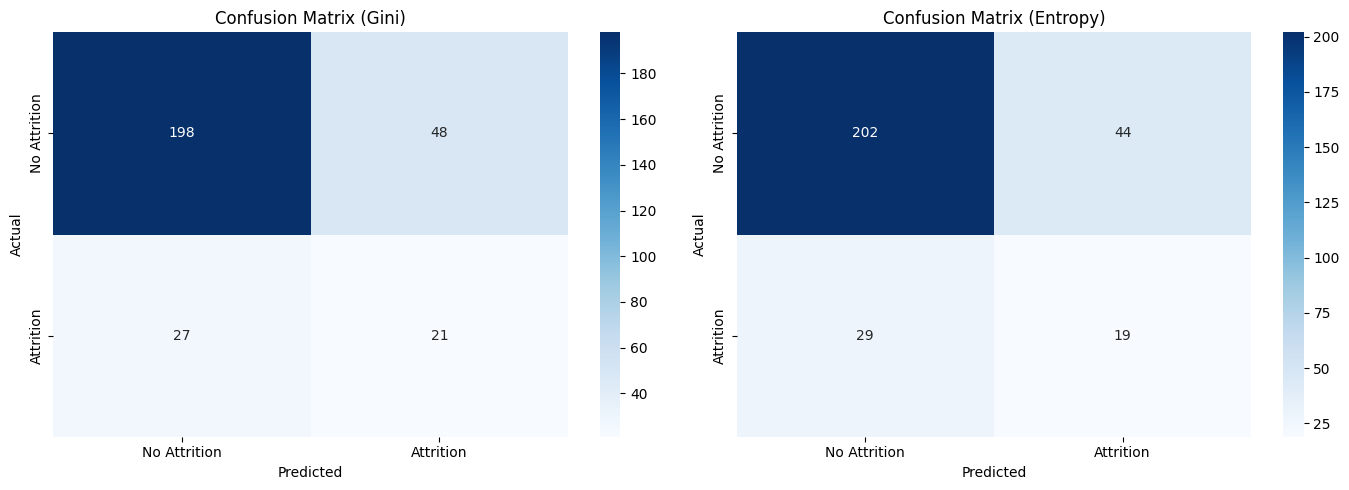

In [20]:
# Confusion Matrix (Gini)
cm_gini = confusion_matrix(y_test, y_pred_gini)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_gini, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
axes[0].set_title("Confusion Matrix (Gini)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion Matrix (Entropy)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

sns.heatmap(cm_entropy, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
axes[1].set_title("Confusion Matrix (Entropy)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Tree Visualization

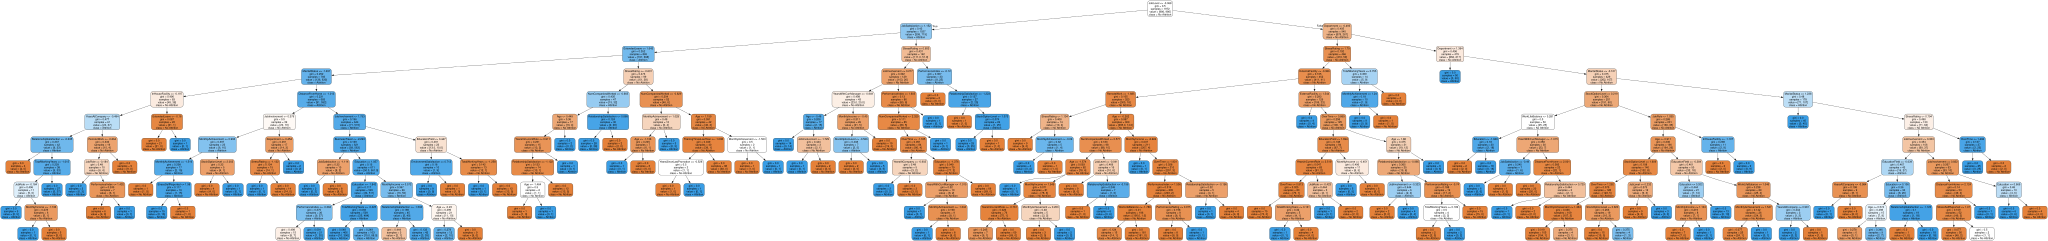

In [21]:
# Visualize using Graphviz (Gini)
sklearn_viz_gini = DecisionTreeClassifier(max_depth=10, criterion='gini', random_state=42)
sklearn_viz_gini.fit(X_train, y_train)

dot_data = export_graphviz(
    sklearn_viz_gini,
    out_file=None,
    feature_names=feature_names,
    class_names=["No Attrition", "Attrition"],
    rounded=True,
    filled=True,
    max_depth=10 
)
graph = Source(dot_data)
graph

## ROC Curve & AUC

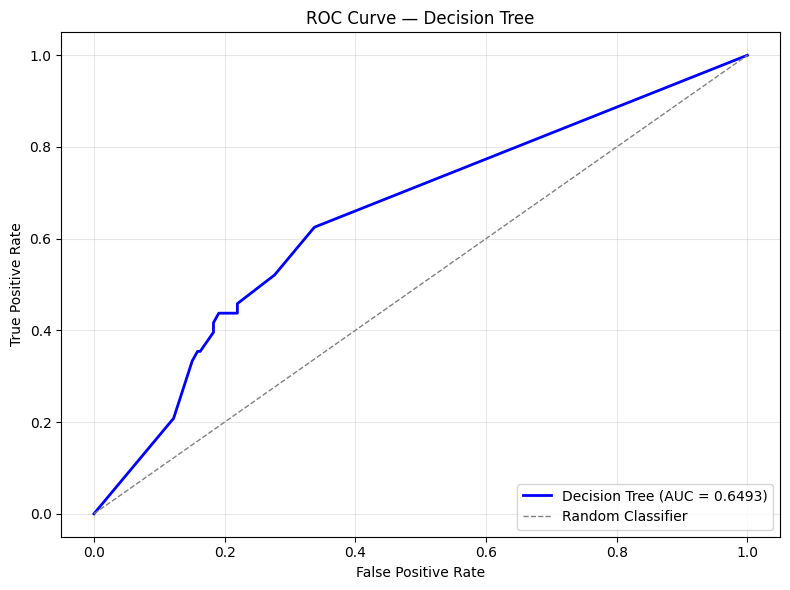

AUC Score: 0.6493


In [22]:
sklearn_dt_roc = DecisionTreeClassifier(max_depth=10, random_state=42)
sklearn_dt_roc.fit(X_train, y_train)
y_scores = sklearn_dt_roc.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

---
# Sklearn Decision Tree — Comparison

In [23]:
sklearn_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
sklearn_dt.fit(X_train, y_train)
y_pred_sklearn = sklearn_dt.predict(X_test)

acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
tp_sk = np.sum((y_pred_sklearn == 1) & (y_test == 1))
tn_sk = np.sum((y_pred_sklearn == 0) & (y_test == 0))
fp_sk = np.sum((y_pred_sklearn == 1) & (y_test == 0))
fn_sk = np.sum((y_pred_sklearn == 0) & (y_test == 1))
prec_sk = tp_sk / (tp_sk + fp_sk) if (tp_sk + fp_sk) > 0 else 0
rec_sk = tp_sk / (tp_sk + fn_sk) if (tp_sk + fn_sk) > 0 else 0
spec_sk = tn_sk / (tn_sk + fp_sk) if (tn_sk + fp_sk) > 0 else 0
f1_sk = 2 * prec_sk * rec_sk /  (prec_sk + rec_sk) if (prec_sk + rec_sk) > 0 else 0

print("=" * 45)
print("  Sklearn Decision Tree — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {acc_sklearn:.4f}")
print(f"  Precision:   {prec_sk:.4f}")
print(f"  Recall:      {rec_sk:.4f}")
print(f"  Specificity: {spec_sk:.4f}")
print(f"  F1 Score:    {f1_sk:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sklearn, target_names=['No Attrition', 'Attrition']))

  Sklearn Decision Tree — Evaluation Results
  Accuracy:    0.7517
  Precision:   0.3077
  Recall:      0.4167
  Specificity: 0.8171
  F1 Score:    0.3540

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.88      0.82      0.85       246
   Attrition       0.31      0.42      0.35        48

    accuracy                           0.75       294
   macro avg       0.59      0.62      0.60       294
weighted avg       0.78      0.75      0.77       294



## Comparison Summary

In [24]:
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"],
    "DT Gini (Scratch)": [acc_gini, prec_gini, rec_gini, spec_gini, f1_gini],
    "DT Entropy (Scratch)": [acc_entropy, prec_entropy, rec_entropy, spec_entropy, f1_entropy],
    "DT (Sklearn)": [acc_sklearn, prec_sk, rec_sk, spec_sk, f1_sk]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 70)
print("     Decision Tree Comparison: From Scratch vs Sklearn")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)


     Decision Tree Comparison: From Scratch vs Sklearn
     Metric  DT Gini (Scratch)  DT Entropy (Scratch)  DT (Sklearn)
   Accuracy           0.744898              0.751701      0.751701
  Precision           0.304348              0.301587      0.307692
     Recall           0.437500              0.395833      0.416667
Specificity           0.804878              0.821138      0.817073
   F1 Score           0.358974              0.342342      0.353982
